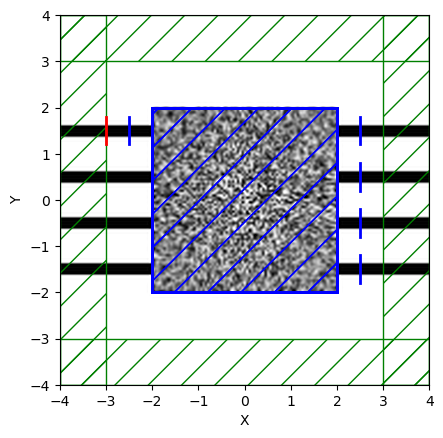

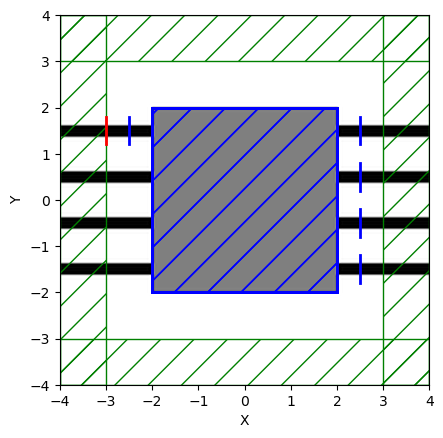

In [12]:
import meep as mp
import meep.adjoint as mpa
import numpy as np
from autograd import numpy as npa
from autograd import tensor_jacobian_product as vjp
from autograd import grad as ag_grad
import nlopt
import matplotlib.pyplot as plt

mp.verbosity(0)

Si = mp.Medium(index=3.4)

resolution = 20

# cell size
Sx = 8
Sy = 8
cell_size = mp.Vector3(Sx, Sy)
pml_layers = [mp.PML(1.0)]

# source
fcen = 1 / 1.55
width = 0.6
fwidth = width * fcen
source_center = mp.Vector3(-3, 1.5, 0)
source_size = mp.Vector3(0, 0.6, 0)
src = mp.GaussianSource(frequency = fcen, fwidth=fwidth)
source = [
    mp.EigenModeSource(
        src,
        eig_band=1,
        eig_match_freq=True,
        direction=mp.X,
        size=source_size,
        center=source_center,
    )
]

#design region
Dx = 4
Dy = 4
design_region_resolution = int(resolution)

Nx = int(Dx * design_region_resolution) + 1
Ny = int(Dy * design_region_resolution) + 1

design_variables = mp.MaterialGrid(mp.Vector3(Nx,Ny),
                                   mp.air,
                                   Si,
                                   grid_type="U_MEAN")
design_region = mpa.DesignRegion(design_variables,
                                 volume=mp.Volume(center=mp.Vector3(),
                                                  size=mp.Vector3(Dx, Dy)))

# geometry
wg_width = 0.25

wg_length = (Sx - Dx) / 2

x_in = -Dx/2 - wg_length/2
x_out = Dx/2 + wg_length/2

# 4개 포트의 y좌표
# 위에서부터 port 1, 2, 3, 4
port_ys = [1.5, 0.5, -0.5, -1.5]

geometry = []

# input / output waveguides
for y in port_ys:
    # input waveguide
    geometry.append(
        mp.Block(
            center=mp.Vector3(x_in, y),
            size=mp.Vector3(wg_length, wg_width, mp.inf),
            material=Si
        )
    )

    # output waveguide
    geometry.append(
        mp.Block(
            center=mp.Vector3(x_out, y),
            size=mp.Vector3(wg_length, wg_width, mp.inf),
            material=Si
        )
    )

# OSU design region
geometry.append(
    mp.Block(
        center=design_region.center,
        size=design_region.size,
        material=design_variables
    )
)

sim = mp.Simulation(
    cell_size=cell_size,
    boundary_layers=pml_layers,
    geometry=geometry,
    sources=source,
    eps_averaging=False,
    resolution=resolution,
)
#input monitor
TE_in = mpa.EigenmodeCoefficient(
    sim,
    mp.Volume(
        center=mp.Vector3(-2.5, 1.5, 0),
        size=mp.Vector3(y=0.6)
    ),
    mode=1,
    forward=True
)

# ouput monitor 
TE_out = []

for y in port_ys:
    TE_out.append(
        mpa.EigenmodeCoefficient(
            sim,
            mp.Volume(
                center=mp.Vector3(2.5, y, 0),
                size=mp.Vector3(y=0.6)
            ),
            mode=1
        )
    )

ob_list = [TE_in] + TE_out

# FOM
def J(a_in, a1, a2, a3, a4):
    Pin = npa.abs(a_in) ** 2 + 1e-12

    powers = npa.array([
        npa.abs(a1) ** 2,
        npa.abs(a2) ** 2,
        npa.abs(a3) ** 2,
        npa.abs(a4) ** 2
    ])

    T = powers / Pin

    target = 0.25

    mse = npa.mean((T - target) ** 2)

    fom = 1 - mse / (target ** 2)

    return fom


opt = mpa.OptimizationProblem(
    simulation=sim,
    objective_functions=J,
    objective_arguments=ob_list,
    design_regions=[design_region],
    fcen=fcen,
    df=0,
    nf=1,
)

x0 = np.random.rand(Nx * Ny)
opt.update_design([x0])

opt.plot2D(True, frequency=1 / 1.55)
plt.show()

x0 = 0.5 * np.ones((Nx * Ny, ))
opt.update_design([x0])

opt.plot2D(True)
plt.show()



In [16]:
evaluation_history = []
cur_iter = [0]


def get_gradient_array(dJ_du):
    g = dJ_du

    # Meep 버전에 따라 list/tuple로 감싸져 나오는 경우 대비
    while isinstance(g, (list, tuple)):
        g = g[0]

    g = np.real(np.squeeze(np.asarray(g)))
    g = g.reshape(-1)

    return g


def f(v, gradient):
    cur_iter[0] += 1

    fom, dJ_du = opt([v], need_gradient=True)

    fom = float(np.real(np.squeeze(fom)))

    if gradient.size > 0:
        g = get_gradient_array(dJ_du)

        if g.size != Nx * Ny:
            raise ValueError(
                f"Gradient size mismatch: got {g.size}, expected {Nx * Ny}"
            )

        gradient[:] = g

    evaluation_history.append(fom)

    print(f"iter {cur_iter[0]:03d} | FOM = {fom:.8f}")

    return fom


algorithm = nlopt.LD_MMA
solver = nlopt.opt(algorithm, Nx * Ny)

solver.set_lower_bounds(np.zeros(Nx * Ny))
solver.set_upper_bounds(np.ones(Nx * Ny))

solver.set_max_objective(f)
solver.set_maxeval(20)
solver.set_ftol_rel(1e-5)

x = solver.optimize(x0)

opt.update_design([x])

Starting forward run...


Starting adjoint run...


Calculating gradient...
iter 001 | FOM = 0.57324858
Starting forward run...


Starting adjoint run...


Calculating gradient...
iter 002 | FOM = 0.62289354
Starting forward run...


...

Calculating gradient...
iter 018 | FOM = 0.99697930
Starting forward run...


Starting adjoint run...


Calculating gradient...
iter 019 | FOM = 0.99725991
Starting forward run...


Starting adjoint run...


Calculating gradient...
iter 020 | FOM = 0.99744391


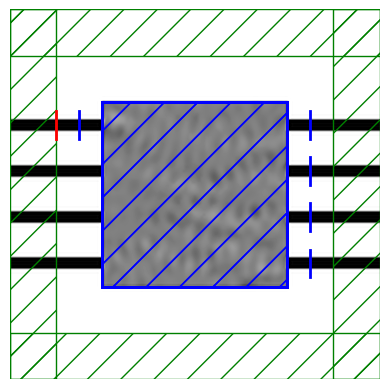

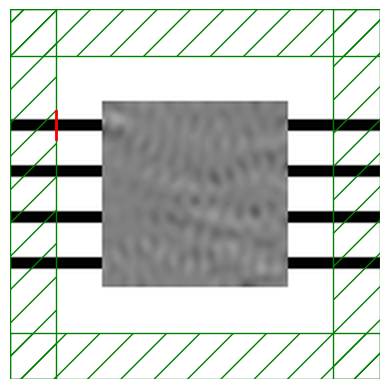

In [17]:
opt.update_design([x])
opt.plot2D(
    True,
    plot_monitors_flag=False,
    output_plane=mp.Volume(center=(0,0,0), size=(8,8,0))
)
plt.axis("off")

opt.update_design([x])

plt.figure()
sim.plot2D(
    output_plane=mp.Volume(center=mp.Vector3(), size=mp.Vector3(8,8,0)),
    labels=False
)
plt.axis("off")
plt.show()

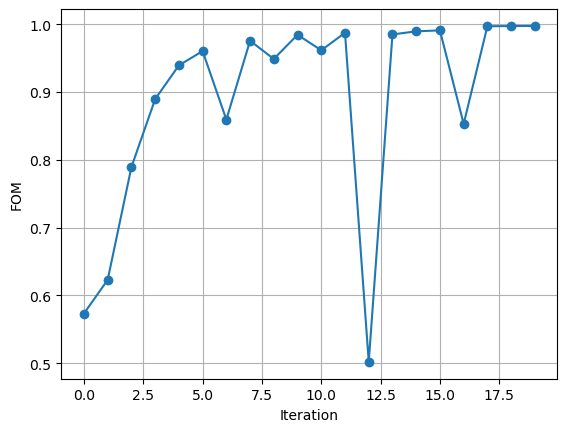

In [18]:
plt.figure()
plt.plot(evaluation_history, "o-")
plt.grid(True)
plt.xlabel("Iteration")
plt.ylabel("FOM")
plt.show()

In [19]:
# ============================================================
# Paper-style intensity plot
# ============================================================

def plot_paper_style_intensity(
    x_plot,
    field_component=mp.Ez,
    vmax=2.0,
    input_port_index=0,
    savefig=False,
    filename="splitter_intensity.png"
):
    """
    첨부 그림처럼 intensity plot을 그리는 함수.

    x_plot:
        최적화된 design variable. 예: x

    field_component:
        2D Ez-like mode면 mp.Ez.
        만약 field가 잘 안 보이면 mp.Hz로 바꿔서 테스트.

    vmax:
        colorbar 최대값. 첨부 그림처럼 2.0으로 설정.

    input_port_index:
        현재 excitation된 input port index.
        port_ys = [1.5, 0.5, -0.5, -1.5] 기준
        0이면 맨 위 port에 input 1 표시.

    savefig:
        True면 png로 저장.
    """

    # --------------------------------------------------------
    # 1. 최적화된 구조 반영
    # --------------------------------------------------------
    opt.update_design([x_plot])

    # 이전 run의 field/monitor 상태 초기화
    sim.reset_meep()

    # --------------------------------------------------------
    # 2. DFT field monitor 추가
    # --------------------------------------------------------
    field_plane = mp.Volume(
        center=mp.Vector3(0, 0, 0),
        size=mp.Vector3(Sx, Sy, 0)
    )

    dft_fields = sim.add_dft_fields(
        [field_component],
        fcen,
        0,
        1,
        where=field_plane
    )

    # --------------------------------------------------------
    # 3. Forward simulation
    # --------------------------------------------------------
    decay_point = mp.Vector3(2.5, port_ys[input_port_index], 0)

    sim.run(
        until_after_sources=mp.stop_when_fields_decayed(
            50,
            field_component,
            decay_point,
            1e-8
        )
    )

    # --------------------------------------------------------
    # 4. Field intensity 계산
    # --------------------------------------------------------
    field = sim.get_dft_array(dft_fields, field_component, 0)
    intensity = np.abs(field) ** 2

    # --------------------------------------------------------
    # 5. Input waveguide intensity 기준으로 normalize
    # --------------------------------------------------------
    xs = np.linspace(-Sx / 2, Sx / 2, intensity.shape[0])
    ys = np.linspace(-Sy / 2, Sy / 2, intensity.shape[1])
    X, Y = np.meshgrid(xs, ys, indexing="ij")

    input_y = port_ys[input_port_index]

    # source와 design region 사이의 input waveguide 구간
    # design region 왼쪽 edge가 x=-2이므로, 그 앞쪽에서 normalization
    input_mask = (
        (X > -2.8) &
        (X < -2.2) &
        (np.abs(Y - input_y) < wg_width / 2)
    )

    if np.sum(input_mask) > 0:
        # input guide 안의 peak intensity를 1 근처로 맞춤
        input_ref = np.percentile(intensity[input_mask], 99)
    else:
        input_ref = np.max(intensity)

    intensity_norm = intensity / (input_ref + 1e-20)

    # --------------------------------------------------------
    # 6. 구조 overlay용 dielectric array
    # --------------------------------------------------------
    eps = sim.get_array(
        center=mp.Vector3(0, 0, 0),
        size=mp.Vector3(Sx, Sy, 0),
        component=mp.Dielectric
    )

    extent = [-Sx / 2, Sx / 2, -Sy / 2, Sy / 2]

    # eps array용 좌표
    xs_eps = np.linspace(-Sx / 2, Sx / 2, eps.shape[0])
    ys_eps = np.linspace(-Sy / 2, Sy / 2, eps.shape[1])
    Xeps, Yeps = np.meshgrid(xs_eps, ys_eps, indexing="ij")

    eps_norm = (eps - np.min(eps)) / (np.max(eps) - np.min(eps) + 1e-20)
    eps_masked = np.ma.masked_where(eps_norm < 0.08, eps_norm)

    # --------------------------------------------------------
    # 7. Plot
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(7.2, 6.0))

    im = ax.imshow(
        intensity_norm.T,
        origin="lower",
        extent=extent,
        cmap="magma",
        interpolation="spline36",
        vmin=0,
        vmax=vmax
    )

    # Si 구조를 회색으로 overlay
    ax.imshow(
        eps_masked.T,
        origin="lower",
        extent=extent,
        cmap="gray",
        interpolation="none",
        alpha=0.45,
        vmin=0,
        vmax=1
    )

    # 구조 edge contour
    try:
        contour_level = 0.5 * (np.min(eps) + np.max(eps))
        ax.contour(
            Xeps,
            Yeps,
            eps,
            levels=[contour_level],
            colors="0.65",
            linewidths=0.45,
            alpha=0.9
        )
    except Exception:
        pass

    # --------------------------------------------------------
    # 8. Text annotations
    # --------------------------------------------------------
    ax.text(
        -3.0,
        2.65,
        r"$\lambda$ = 1.55 $\mu$m",
        color="white",
        fontsize=24,
        fontweight="bold"
    )

    # 왼쪽 input labels: excited port만 1, 나머지 0
    for i, y in enumerate(port_ys):
        label = "1" if i == input_port_index else "0"

        ax.text(
            -3.45,
            y + 0.02,
            label,
            color="white",
            fontsize=17,
            fontweight="bold",
            ha="center",
            va="center"
        )

    # 오른쪽 output labels
    for y in port_ys:
        ax.text(
            3.25,
            y + 0.02,
            "0.25",
            color="white",
            fontsize=17,
            fontweight="bold",
            ha="center",
            va="center"
        )

    # --------------------------------------------------------
    # 9. Colorbar / axis styling
    # --------------------------------------------------------
    cbar = fig.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

    cbar.set_ticks([0, 0.5, 1.0, 1.5, 2.0])
    cbar.ax.tick_params(labelsize=15)

    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    plt.tight_layout()

    if savefig:
        plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

    return intensity_norm, eps